In [46]:
import numpy as np
from scipy.stats import chi2, multivariate_normal, norm, uniform, vonmises, gamma
import seaborn as sns

import warnings
import sys
from os import path, getcwd
import pathlib

# where everything is stored (data and code)
ROOT = pathlib.Path(getcwd()).parent.absolute()
# code paths
sys.path.append(path.join(ROOT, 'src/models'))
sys.path.append(path.join(ROOT, 'src/exp'))
sys.path.append(path.join(ROOT, 'src/common'))

from inflation.jupyter_helper import *
from plotting.stats import *
warnings.simplefilter(action='ignore', category=FutureWarning)

In [2]:
def NICE_old(X, Y):
    X = np.double(X)
    Y = np.double(Y)
    # initialisation
    X_1 = X
    Y_1 = Y

    X_2 = X_1
    # encode X_1 in higher values
    scaler = 2**20
    print(f'Scale Factor: {scaler}')
    #scaler = 2**40
    #scaler = 1000
    # use this if you want to see the effect
    #scaler = 1000000000 
    Y_2 = Y_1 + X_1 * scaler
    # you can use the following line, this way you can see how X_1 is encoded on top of Y_1
    # 6 you can see one 0
    #Y_2 = Y_1 + np.around(X_1, 6) * scaler

    # make X_3 approximately 0
    X_3 = X_2 - Y_2 / scaler
    Y_3 = Y_2
    # this would (with high probability) cut of Y_1, but lets stick to the "usual" neural net operations
    # X_3 = X_2 - (np.around(Y_2/10, 0) / (scaler/10))

    # do nothing layer
    X_4 = X_3
    Y_4 = Y_3

    # store Y_4 on something that is close to 0
    X_5 = X_4 + Y_4
    Y_5 = Y_4
    
    #return X_5, Y_5

    # now X_5 and Y_5 contain approximately the same value
    # we will now make them arbitrarily small
    # this would work in a single step, but feels more intuitive that way.
    A = X_5
    B = Y_5
    scale_down_factor = 2
    for i in range(50):
        OLD_A = A
        OLD_B = B
        A = A - B / 2
        B = B

        A = A
        B = B - A

        x_percent = len(A) * 0.03
        # could be done by hand / gradient descent
        if np.sum(np.abs(A) > np.abs(OLD_A)) > x_percent or np.sum(np.abs(B) > np.abs(OLD_B)) > x_percent:
            break
    print(f'Stopped after {i} down scalings')
            
    return A, B

In [3]:
def NICE(X, Y):
    X = np.double(X)
    Y = np.double(Y)
    # initialisation
    X_1 = X
    Y_1 = Y

    X_2 = X_1
    # encode X_1 in higher values
    scaler = 10000 
    print(f'Scale Factor: {scaler}')
    
    Y_2 = Y_1 + np.around(X_1, int(np.log10(scaler))) * scaler

    X_3 = X_2 - (np.around(Y_2/10, 0) / (scaler/10))
    Y_3 = Y_2
    
    # do nothing layer
    X_4 = X_3
    Y_4 = Y_3

    # store Y_4 on something that is close to 0
    X_5 = X_4 + Y_4
    Y_5 = Y_4
    
    #return X_5, Y_5

    # now X_5 and Y_5 contain approximately the same value
    # we will now make them arbitrarily small
    # this would work in a single step, but feels more intuitive that way.
    A = X_5
    B = Y_5
    scale_down_factor = 2
    for i in range(50):
        OLD_A = A
        OLD_B = B
        A = A - B / 2
        B = B

        A = A
        B = B - A

        x_percent = len(A) * 0.01
        # could be done by hand / gradient descent
        if np.sum(np.abs(A) > np.abs(OLD_A)) > x_percent or np.sum(np.abs(B) > np.abs(OLD_B)) > x_percent:
            break
    print(f'Stopped after {i} down scalings')
            
    return A, B

In [47]:

def cut_off_quantile_from_S(S, T, alpha):
    argsorted = np.argsort(S)
    S = S[argsorted]
    T = T[argsorted]
    cut_left = int(len(S) * alpha)
    cut_right = int(len(S) * (1-alpha)) - 1
    
    S = S[cut_left : cut_right]
    T = T[cut_left : cut_right]
    return S, T

def plot_learned_density_state(A, B, ax):
    print('First 10 entries of f(X,Y)')
    print(A[:10], B[:10])
    
    #### Plotting
    learned_pdf = norm.pdf(A)*norm.pdf(B)
    ax.set_title('Model State Density')
    sns.distplot(learned_pdf, ax=ax, label=f'q_X Mean: {learned_pdf.mean():.3f}', color='g', hist=True, bins=1000, kde_kws={'bw_adjust': 0.1}, kde=True)

    ax.set_ylim(top=150)
    ax.set_xlabel('p(X)')
    ax.set_ylabel('p( p(X) )')

    ax.legend()
    
def approx_and_plot_pdf(A, B, axs, data_cut_quantile=0.02):
    ### approx density plotting
    S = A.copy()
    T = B.copy()
    # it is enough to cut of from from A, as high B correlate with this
    
    S, T = cut_off_quantile_from_S(S=S, T=T, alpha=data_cut_quantile)

    print(f'use f(X,Y)[0] {data_cut_quantile} quantiles: ', quantile_finder(S, 0))
    print(f'use f(X,Y)[1] {data_cut_quantile} quantiles: ', quantile_finder(T, 0))
    bin_count = 200
    likelihood_samples, histo_density, _ = approx_density(S, T, alpha=0, bin_count=bin_count)
    a = np.array(likelihood_samples)
    print(a.var(), np.log(a).var())
    sns.distplot(np.log(likelihood_samples), ax=axs[0], label='approx NICE(X, Y)', color='tab:olive', hist=True,
    #sns.distplot(likelihood_samples, ax=axs[0], label='approx NICE(X, Y)', color='tab:olive', hist=True,
                 bins=100, kde_kws={'bw_adjust': 0.8}, kde=True)

    likelihood_samples, true_histo, _ = approx_density(X, Y, alpha=0.005, bin_count=bin_count)
    #sns.distplot(np.log(likelihood_samples), ax=axs[0], label='approx X, Y', color='tab:pink', hist=True,
    #sns.distplot(likelihood_samples, ax=axs[0], label='approx X, Y', color='tab:pink', hist=True,
    #             bins=100, kde_kws={'bw_adjust': 0.8}, kde=True)

    axs[0].set_title('Approximated True State Density')
    axs[0].set_xlabel('log p(X)')
    axs[0].set_ylabel('p( log p(X) )')

    axs[0].legend()
    #print(histo_density)
    
    sns.heatmap(true_histo, ax=axs[1], xticklabels=False, yticklabels=False)
    sns.heatmap(histo_density, ax=axs[2], xticklabels=False, yticklabels=False)
    
    axs[1].set_title('Approximated true PDF')
    axs[2].set_title('Approximated learned PDF')
    

def do_it_all_together(X, Y, true_pdf, data_cut_quantile, name):
    A, B = NICE(X, Y)

    fig, axs = plt.subplots(nrows=4, ncols=1, figsize=(20, 20), squeeze=True, gridspec_kw={'height_ratios': [1, 1, 2, 2]})
    sns.distplot(true_pdf, ax=axs[0], label='p_X', color='r', hist=True, bins=1000, kde_kws={'bw_adjust': 0.1}, kde=True)
    sns.distplot(np.log(true_pdf), ax=axs[1], label='p_X', color='r', hist=False, bins=1000, kde_kws={'bw_adjust': 0.8}, kde=True)
    
    plot_learned_density_state(A, B, axs[0])
    approx_and_plot_pdf(A, B, axs[1:], data_cut_quantile)
    
    plt.suptitle(f'{name}', size=22, y=0.92)
    fig.savefig(f'random/hack_{name}.png')
    return (fig, axs), (A, B)


In [36]:
f'{0.005**2:1.10}'

'2.5e-05'

use f(X,Y)[0] 0.005 quantiles:  (-3.6497124649328576, 3.6458874713889684)
use f(X,Y)[1] 0.005 quantiles:  (-0.0386591695210646, 0.03894342942318086)
260.9954169612317 0.40035069835487985
use f(X,Y)[0] 0 quantiles:  (-0.28333876908389855, 0.2836537589076198)
use f(X,Y)[1] 0 quantiles:  (-0.289808149151085, 0.28460161469082546)
257.54650877347166 0.5287934800788171


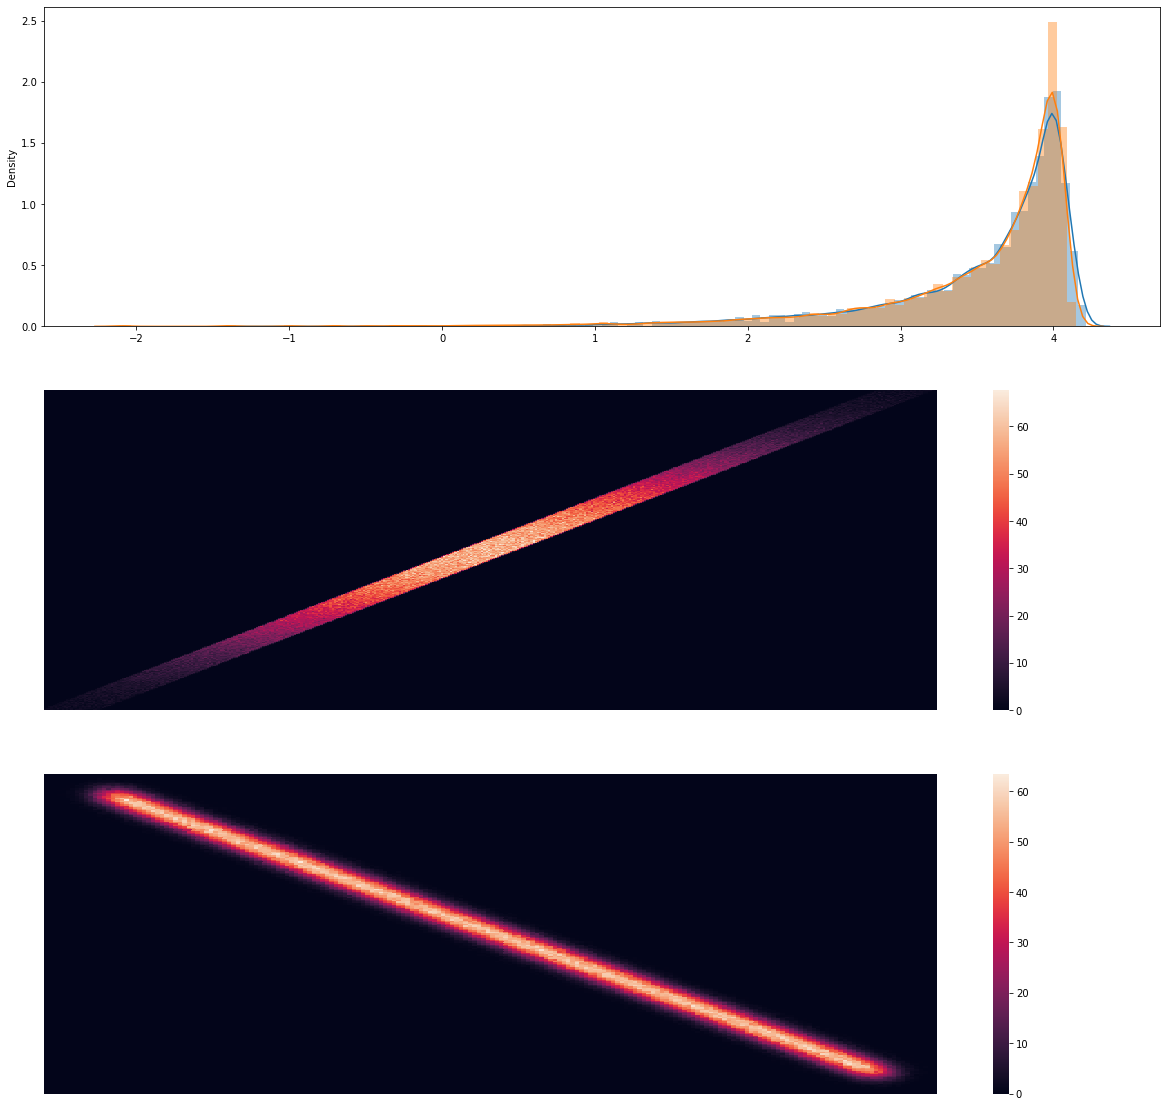

In [55]:
def forget_func_name(S, T, ax_1, ax_2, data_cut_quantile, bin_count):
    S = S.copy()
    T = T.copy()
    S, T = cut_off_quantile_from_S(S=S, T=T, alpha=data_cut_quantile)

    print(f'use f(X,Y)[0] {data_cut_quantile} quantiles: ', quantile_finder(S, 0))
    print(f'use f(X,Y)[1] {data_cut_quantile} quantiles: ', quantile_finder(T, 0))
    
    likelihood_samples, histo_density, _ = approx_density(S, T, alpha=0, bin_count=bin_count)
    a = np.array(likelihood_samples)
    print(a.var(), np.log(a).var())
    sns.distplot(np.log(likelihood_samples), ax=ax_1, label='approx NICE(X, Y)', hist=True,
    #sns.distplot(likelihood_samples, ax=axs[0], label='approx NICE(X, Y)', color='tab:olive', hist=True,
                 bins=100, kde_kws={'bw_adjust': 0.8}, kde=True)

    sns.heatmap(histo_density, ax=ax_2, xticklabels=False, yticklabels=False)

eps = 0.01
SIZE = 1000000
B = norm.rvs(size=SIZE) 
C = norm.rvs(size=SIZE)
A = uniform.rvs(loc=-0.5, size=SIZE)
#A = norm.rvs(size=SIZE, scale=1)

B = np.double(B)
C = np.double(C)
A = np.double(A)

original_first = 0.5 * A + eps * B
original_second = 0.5 * A + eps * C

#first = -phi + psi
#second = 0.5*eps * A + eps * phi + (eps**2-eps) * psi
first = B - C
second = 0.5*eps*A  + (eps**2-eps) * B + eps * C

fig, axs = plt.subplots(nrows=3, ncols=1, figsize=(20, 20), squeeze=True)

forget_func_name(first, second, axs[0], axs[1], data_cut_quantile=0.005, bin_count=400)
forget_func_name(original_first, original_second, axs[0], axs[2], data_cut_quantile=0, bin_count=200)

In [11]:
sample_size = 1000000

Scale Factor: 10000
Stopped after 11 down scalings
First 10 entries of f(X,Y)
[ 0.56172555  6.5339847   6.13111237  3.16928072 12.5191507   2.18888505
  1.58440972  2.29206346 21.80379318  5.16598038] [ 2.72575521  6.51824586  8.29483928  3.96250597 12.81330206  1.78386558
  1.11768441  3.40589219 20.83377658  5.5258127 ]
use f(X,Y)[0] 0.02 quantiles:  (-0.1523707695273453, 21.582000470869925)
use f(X,Y)[1] 0.02 quantiles:  (-0.6935215626705397, 25.88995775630675)
0.0009254713047900971 0.06971322530609811


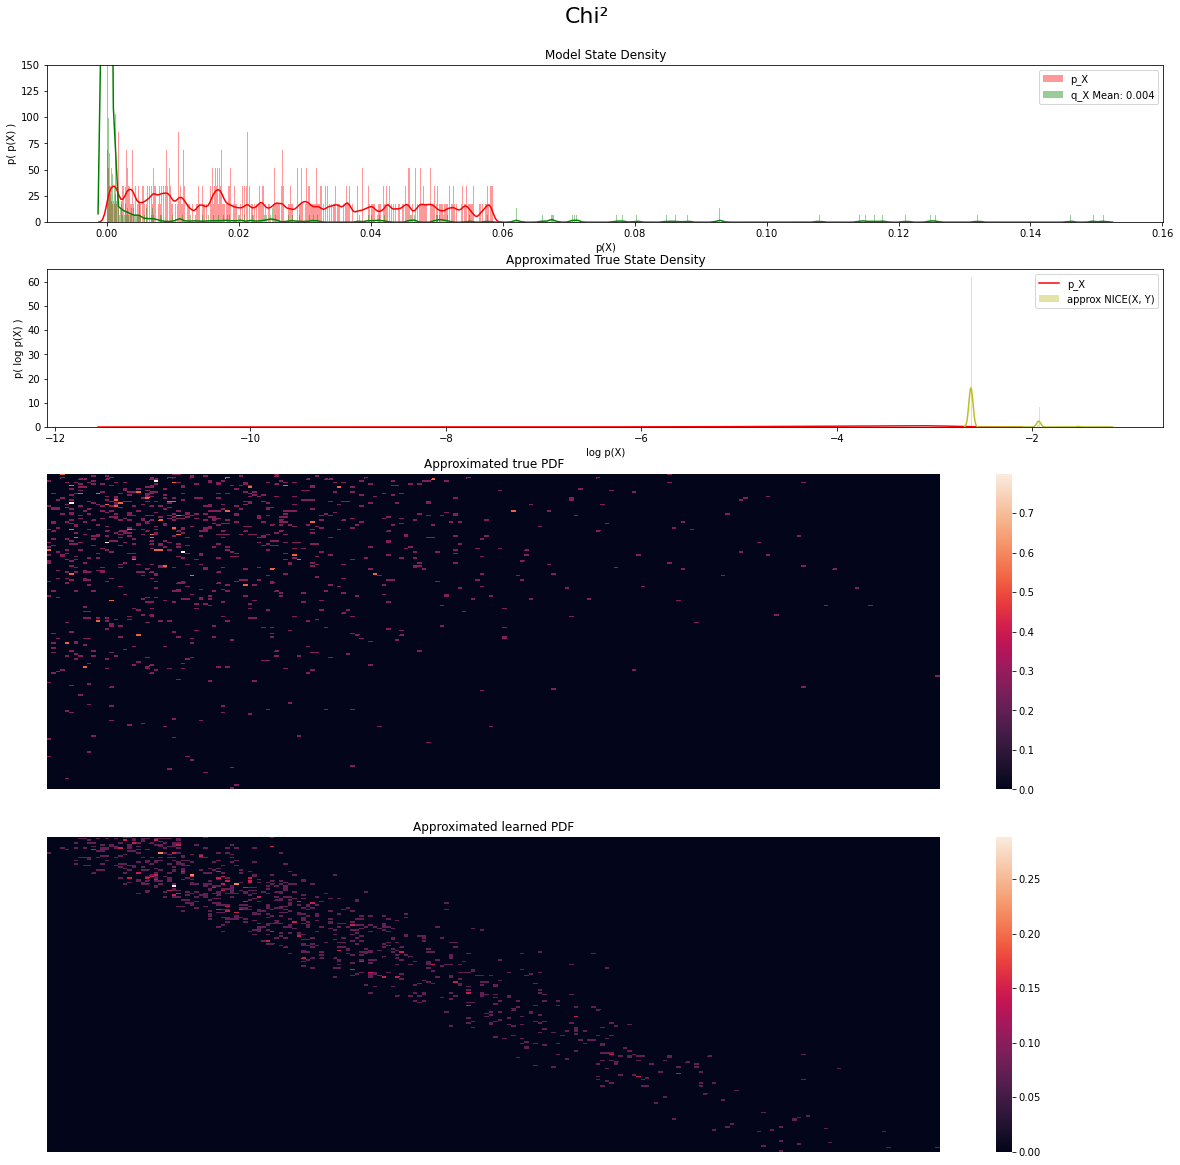

In [16]:
sample_size = 1000
chi2_df = 3
X, Y = chi2.rvs(df=chi2_df, size=(2, sample_size))
true_pdf = chi2.pdf(X, df=chi2_df) * chi2.pdf(Y, df=chi2_df)

(fig, axs), _=do_it_all_together(X, Y, true_pdf, data_cut_quantile=0.02, name='Chi²')
#(fig, axs), _=do_it_all_together(X, Y, true_pdf, data_cut_quantile=0.02, name='Chi²')
#_=axs[1].set_ylim(top=30)

First 10 entries of f(X,Y)
[ 4.22632697 -0.47521132  0.4597658   1.06018021  0.28651937  0.84367782
 -1.18105129  0.38346749  2.41029889  1.94606816] [ 4.22733906 -0.33330332  1.38665269  0.2632881  -0.34904384  1.5996885
 -1.15967949  0.59587586  2.05861959  1.78114486]
use f(X,Y)[0] 0.0 quantiles:  (-7.4269263373820955, 7.510084130291279)
use f(X,Y)[1] 0.0 quantiles:  (-7.76143770996122, 7.465715768120635)
Total Mass: 1.000
0.0021041756218926717 0.9631683997383539
Total Mass: 1.000


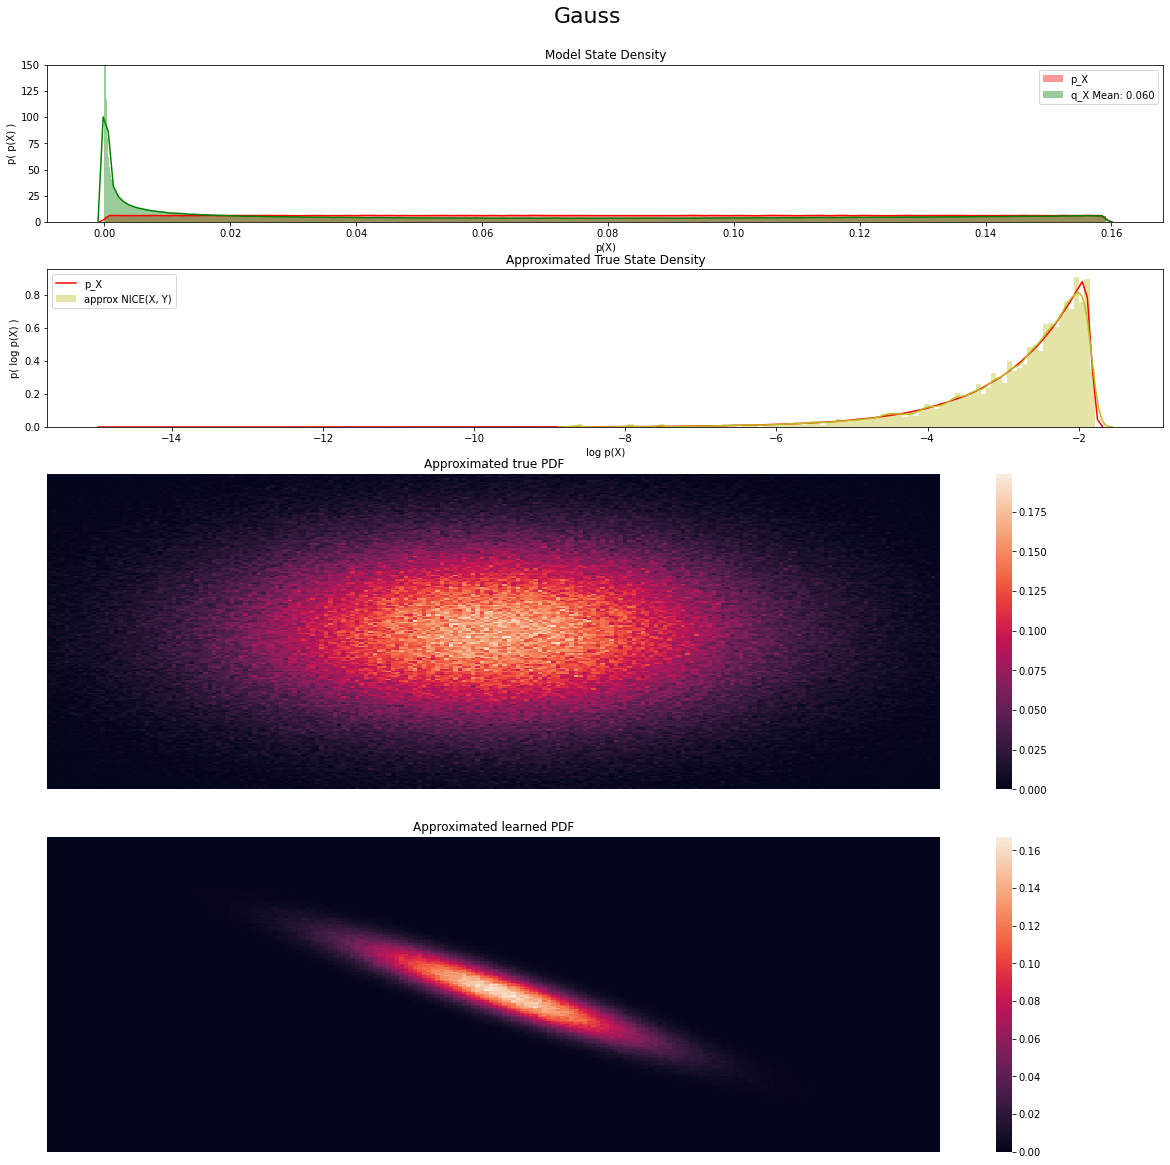

In [46]:
X, Y = norm.rvs(size=(2, sample_size))
true_pdf = norm.pdf(X)*norm.pdf(Y)
(fig, axs), _ = do_it_all_together(X, Y, true_pdf, data_cut_quantile=0.00, name='Gauss')

In [50]:
#args = dict(a=2, scale=1/2)
#X, Y = gamma.rvs(size=(2, sample_size), **args)
#true_pdf = gamma.pdf(X, **args)*gamma.pdf(Y, **args)
#(fig, axs), _ = do_it_all_together(X, Y, true_pdf, data_cut_quantile=0.00, name='Gamma')

49
First 10 entries of f(X,Y)
[ 0.00263475 -0.00093549 -0.00063217 -0.0014232   0.00129416  0.00037292
  0.00294292  0.00114179 -0.00064043  0.00274568] [ 0.00263475 -0.00093549 -0.00063217 -0.0014232   0.00129416  0.00037292
  0.00294292  0.00114179 -0.00064043  0.00274568]
use f(X,Y)[0] 0.0 quantiles:  (-0.004220878794779542, 0.004153495799003123)
use f(X,Y)[1] 0.0 quantiles:  (-0.004220878794779542, 0.004153495799003123)
Total Mass: 1.000
Total Mass: 1.000


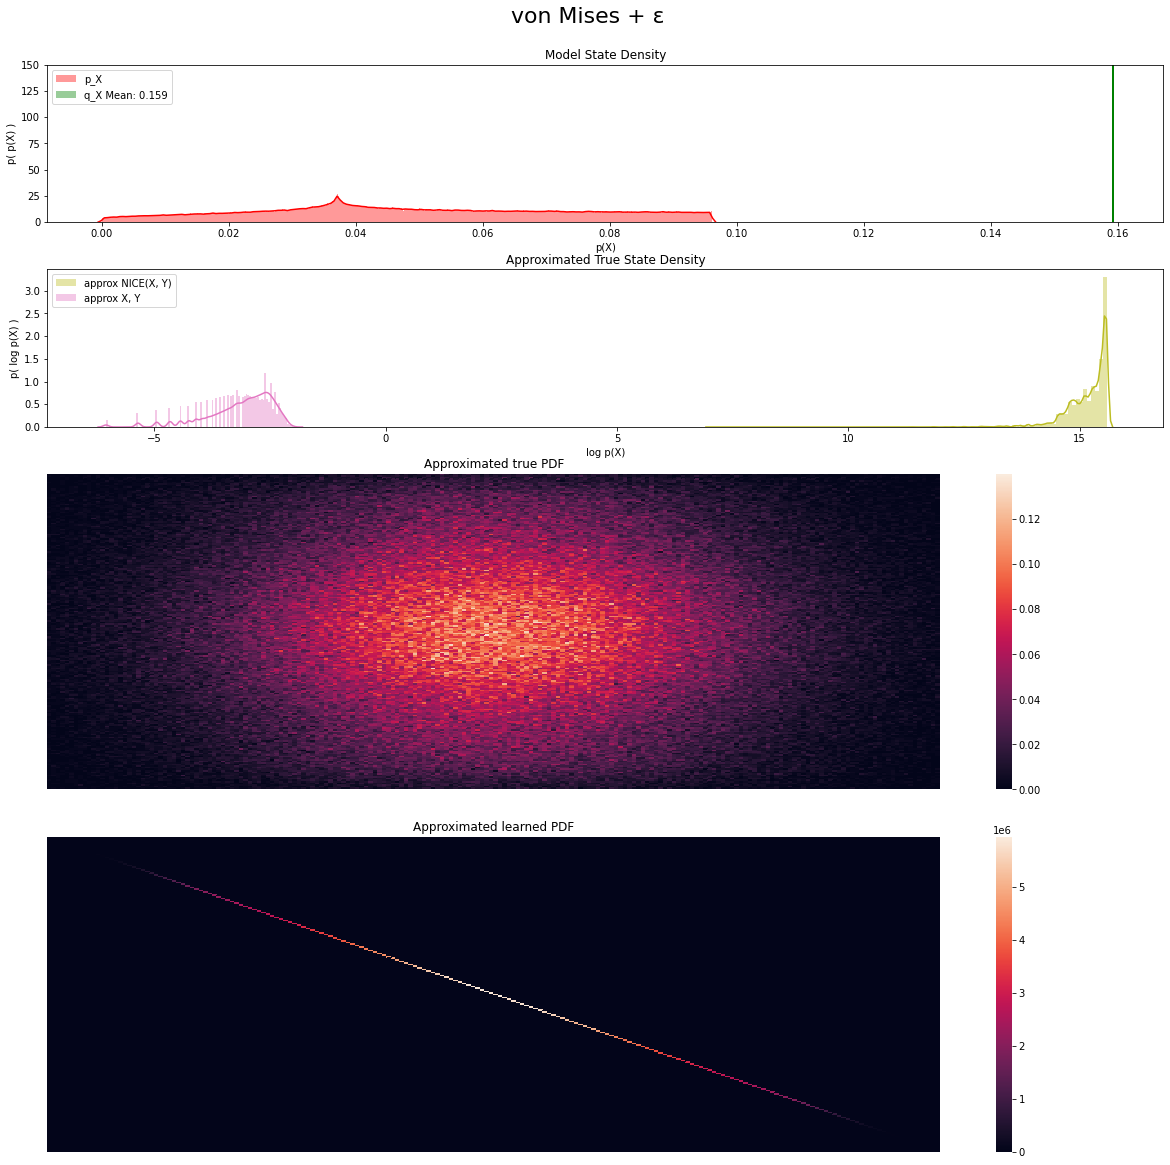

In [8]:
mises_sample_size = int(sample_size/2)  # needs ages just to sample
#mises_sample_size = sample_size
kappa = 0.5
scale = np.sqrt(10**-1)
X = vonmises.rvs(kappa=kappa, size=mises_sample_size) + norm.rvs(size=mises_sample_size, scale=scale)
Y = norm.rvs(size=mises_sample_size)

# convolution to approximate pdf(X)
random_norm_samples = norm.rvs(size=1000, scale=scale)
pdfs = []
for x in X:
    x_pdf = np.mean(vonmises.pdf(x - random_norm_samples, kappa=kappa), axis=0)
    pdfs.append(x_pdf)
pdfs = np.array(pdfs)

true_pdf = pdfs*norm.pdf(Y)
(axs,fig), _ =do_it_all_together(X, Y, true_pdf, data_cut_quantile=0.00, name='von Mises + ε')